##Install Pyspark

In [1]:
# Colab already has Java installed, so Spark can be installed easily with pip.
!pip install pyspark

In [2]:
import pyspark
print(pyspark.__file__)

/usr/local/lib/python3.12/dist-packages/pyspark/__init__.py


## Start a SparkSession
This will start a local Spark session.

In [13]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("Cluster").getOrCreate()

file_path = "process_data_Sampling_Topic_sampling_post.parquet"
df = spark.read.parquet(file_path)

print(f"จำนวนแถวทั้งหมด: {df.count()} แถว")
print(f"จำนวนคอลัมน์ทั้งหมด: {len(df.columns)} คอลัมน์")
df.printSchema()
df.show(5)

จำนวนแถวทั้งหมด: 2627 แถว
จำนวนคอลัมน์ทั้งหมด: 19 คอลัมน์
root
 |-- content_categories: string (nullable = true)
 |-- created_utc: string (nullable = true)
 |-- author: string (nullable = true)
 |-- is_crosspostable: boolean (nullable = true)
 |-- num_comments: long (nullable = true)
 |-- num_crossposts: long (nullable = true)
 |-- selftext: string (nullable = true)
 |-- subreddit: string (nullable = true)
 |-- title: string (nullable = true)
 |-- upvote_ratio: double (nullable = true)
 |-- ups: long (nullable = true)
 |-- downs: long (nullable = true)
 |-- view_count: string (nullable = true)
 |-- AI_Name: string (nullable = true)
 |-- detected_topics: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- title_clean: string (nullable = true)
 |-- rawPrediction: vector (nullable = true)
 |-- prediction: double (nullable = true)
 |-- row_id: long (nullable = true)

+------------------+-------------------+-----------------+----------------+------------+-----------

In [16]:
from pyspark.ml.feature import Tokenizer, StopWordsRemover, HashingTF, IDF
from pyspark.sql.functions import col, when, lit

# Tokenization: แยกข้อความออกเป็นคำๆ
tokenizer = Tokenizer(inputCol="title_clean", outputCol="words")
df_tokenized = tokenizer.transform(df)

# Stop Words Removal: ลบคำที่ไม่สำคัญออก
remover = StopWordsRemover(inputCol="words", outputCol="filtered_words")
df_filtered = remover.transform(df_tokenized)

# TF-IDF Weighting: คำนวณ TF-IDF เพื่อสร้าง Feature Vector
hashingTF = HashingTF(inputCol="filtered_words", outputCol="raw_features", numFeatures=1000)
df_hashing = hashingTF.transform(df_filtered)

# IDF (Inverse Document Frequency) ปรับน้ำหนักคำที่พบบ่อยให้มีผลน้อยลง
idf = IDF(inputCol="raw_features", outputCol="tfidf_features")
idfModel = idf.fit(df_hashing)
df_tfidf = idfModel.transform(df_hashing)

print(f"จำนวนแถวทั้งหมด: {df_tfidf.count()} แถว")
print(f"จำนวนคอลัมน์ทั้งหมด: {len(df_tfidf.columns)} คอลัมน์")
df_tfidf.printSchema()
df_tfidf.select('title_clean', 'words', 'filtered_words', 'raw_features', 'tfidf_features').show(5, truncate=False)

จำนวนแถวทั้งหมด: 2627 แถว
จำนวนคอลัมน์ทั้งหมด: 23 คอลัมน์
root
 |-- content_categories: string (nullable = true)
 |-- created_utc: string (nullable = true)
 |-- author: string (nullable = true)
 |-- is_crosspostable: boolean (nullable = true)
 |-- num_comments: long (nullable = true)
 |-- num_crossposts: long (nullable = true)
 |-- selftext: string (nullable = true)
 |-- subreddit: string (nullable = true)
 |-- title: string (nullable = true)
 |-- upvote_ratio: double (nullable = true)
 |-- ups: long (nullable = true)
 |-- downs: long (nullable = true)
 |-- view_count: string (nullable = true)
 |-- AI_Name: string (nullable = true)
 |-- detected_topics: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- title_clean: string (nullable = true)
 |-- rawPrediction: vector (nullable = true)
 |-- prediction: double (nullable = true)
 |-- row_id: long (nullable = true)
 |-- words: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- filtered_wo

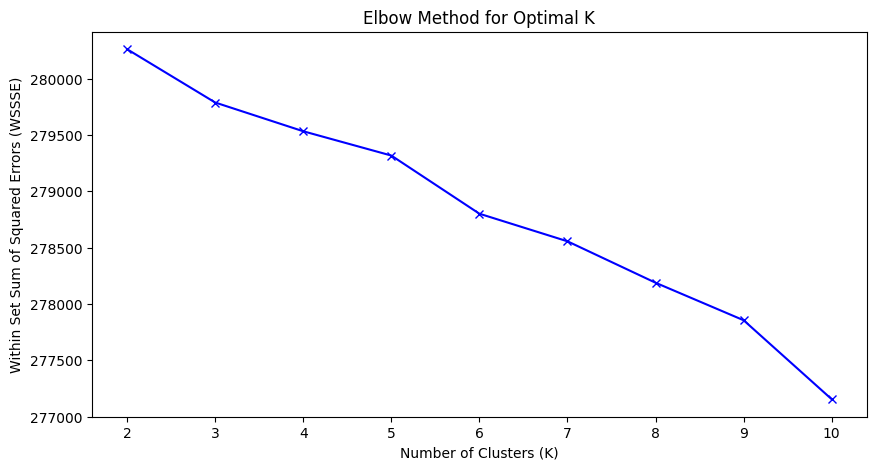

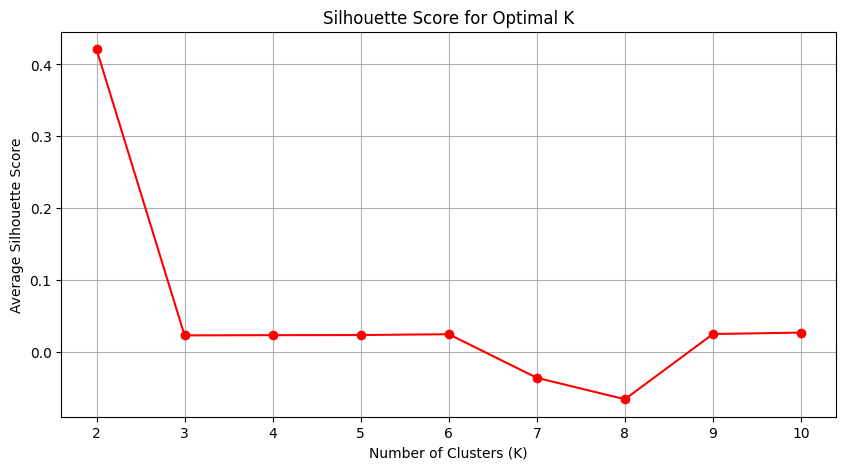

In [19]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
import matplotlib.pyplot as plt

# หาจำนวนกลุ่มที่เหมาะสม (K) โดยใช้ PySpark MLlib
sse = []
silhouette_avg = []
k_range = range(2, 11) # ทดสอบที่ 2 ถึง 10 กลุ่ม

# เตรียม evaluator สำหรับ Silhouette score
evaluator = ClusteringEvaluator(featuresCol="tfidf_features",
                               predictionCol="cluster_prediction",
                               metricName="silhouette",
                               distanceMeasure="squaredEuclidean")

for k in k_range:
    # กำหนดค่า KMeans สำหรับ PySpark
    kmeans = KMeans(featuresCol="tfidf_features", k=k, seed=42, predictionCol="cluster_prediction")
    model = kmeans.fit(df_tfidf)

    # สำหรับ Elbow Method (SSE)
    wssse = model.summary.trainingCost # Within Set Sum of Squared Errors
    sse.append(wssse)

    # สำหรับ Silhouette Analysis
    predictions = model.transform(df_tfidf)
    silhouette = evaluator.evaluate(predictions)
    silhouette_avg.append(silhouette)

# Plot Elbow Method
plt.figure(figsize=(10, 5))
plt.plot(k_range, sse, 'bx-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within Set Sum of Squared Errors (WSSSE)')
plt.title('Elbow Method for Optimal K')
plt.show()

# Plot Silhouette Analysis
plt.figure(figsize=(10, 5))
plt.plot(k_range, silhouette_avg, 'ro-')
plt.title('Silhouette Score for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Average Silhouette Score')
plt.xticks(k_range)
plt.grid(True)
plt.show()

In [24]:
from pyspark.ml.clustering import KMeans
import pandas as pd

# ทำ Clustering ด้วย K ที่เลือก
optimal_k = 3
kmeans = KMeans(featuresCol="tfidf_features", k=optimal_k, seed=42, predictionCol="cluster_label")
model = kmeans.fit(df_tfidf)

# Get the predictions as a PySpark DataFrame
df_clustered_spark = model.transform(df_tfidf)

print(f"จำนวนแถวทั้งหมด: {df_clustered_spark.count()} แถว")
print(f"จำนวนคอลัมน์ทั้งหมด: {len(df_clustered_spark.columns)} คอลัมน์")
df_clustered_spark.printSchema()
df_clustered_spark.show(5)

จำนวนแถวทั้งหมด: 2627 แถว
จำนวนคอลัมน์ทั้งหมด: 24 คอลัมน์
root
 |-- content_categories: string (nullable = true)
 |-- created_utc: string (nullable = true)
 |-- author: string (nullable = true)
 |-- is_crosspostable: boolean (nullable = true)
 |-- num_comments: long (nullable = true)
 |-- num_crossposts: long (nullable = true)
 |-- selftext: string (nullable = true)
 |-- subreddit: string (nullable = true)
 |-- title: string (nullable = true)
 |-- upvote_ratio: double (nullable = true)
 |-- ups: long (nullable = true)
 |-- downs: long (nullable = true)
 |-- view_count: string (nullable = true)
 |-- AI_Name: string (nullable = true)
 |-- detected_topics: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- title_clean: string (nullable = true)
 |-- rawPrediction: vector (nullable = true)
 |-- prediction: double (nullable = true)
 |-- row_id: long (nullable = true)
 |-- words: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- filtered_wo

In [25]:
from pyspark.sql import functions as F

# EDA พื้นฐานแต่ละกลุ่ม โดยใช้ PySpark
cluster_eda_spark = df_clustered_spark.groupBy('cluster_label').agg(
    F.count('row_id').alias('count_rows'),
    F.mean('ups').alias('avg_upvotes')
)

print("Cluster EDA Summary:")
cluster_eda_spark.show()

Cluster EDA Summary:
+-------------+----------+-----------------+
|cluster_label|count_rows|      avg_upvotes|
+-------------+----------+-----------------+
|            1|        18|7.388888888888889|
|            2|        10|              0.7|
|            0|      2599|45.41169680646402|
+-------------+----------+-----------------+



Proportion of Topics by Cluster (Including Sentiments):
detected_topics  prod_affordable  prod_performance  prod_usability  \
cluster_label                                                        
0                       0.098143          0.050133        0.057560   
1                       0.100000          0.000000        0.100000   
2                       0.076923          0.076923        0.115385   

detected_topics  sentiment_negative  sentiment_positive  usecase_code  \
cluster_label                                                           
0                          0.061538            0.168966      0.160477   
1                          0.033333            0.233333      0.200000   
2                          0.038462            0.230769      0.115385   

detected_topics  usecase_creative  usecase_data  usecase_research  \
cluster_label                                                       
0                        0.103183      0.040053          0.127851   
1                   

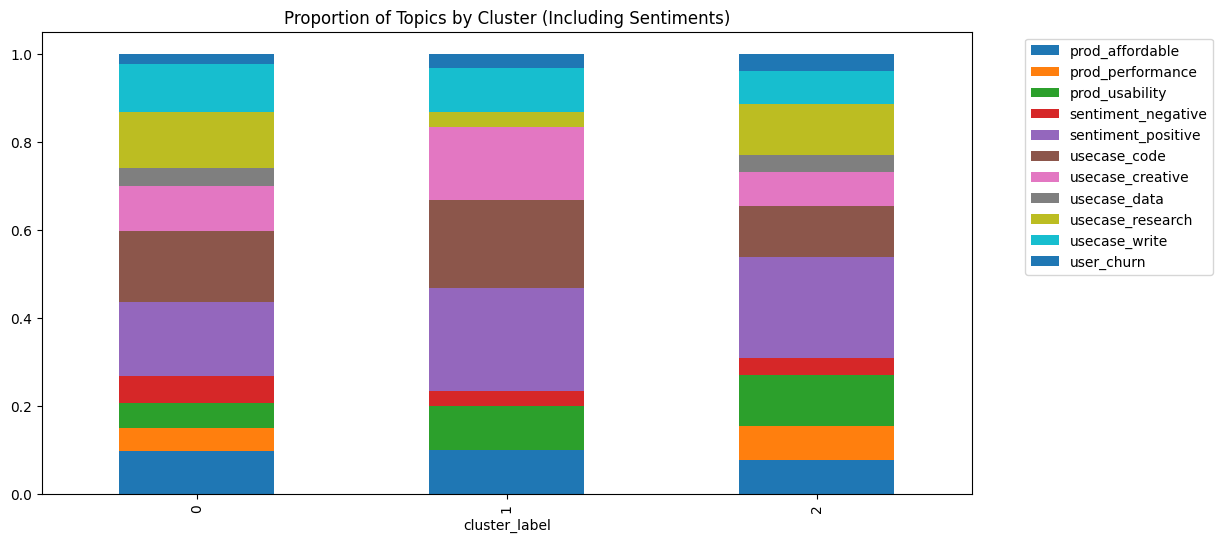

Proportion of each Topic across Clusters (Including Sentiments):
cluster_label              0         1         2
detected_topics                                 
prod_affordable     0.986667  0.008000  0.005333
prod_performance    0.989529  0.000000  0.010471
prod_usability      0.973094  0.013453  0.013453
sentiment_negative  0.991453  0.004274  0.004274
sentiment_positive  0.980000  0.010769  0.009231
usecase_code        0.985342  0.009772  0.004886
usecase_creative    0.982323  0.012626  0.005051
usecase_data        0.993421  0.000000  0.006579
usecase_research    0.991770  0.002058  0.006173
usecase_write       0.987893  0.007264  0.004843
user_churn          0.978261  0.010870  0.010870


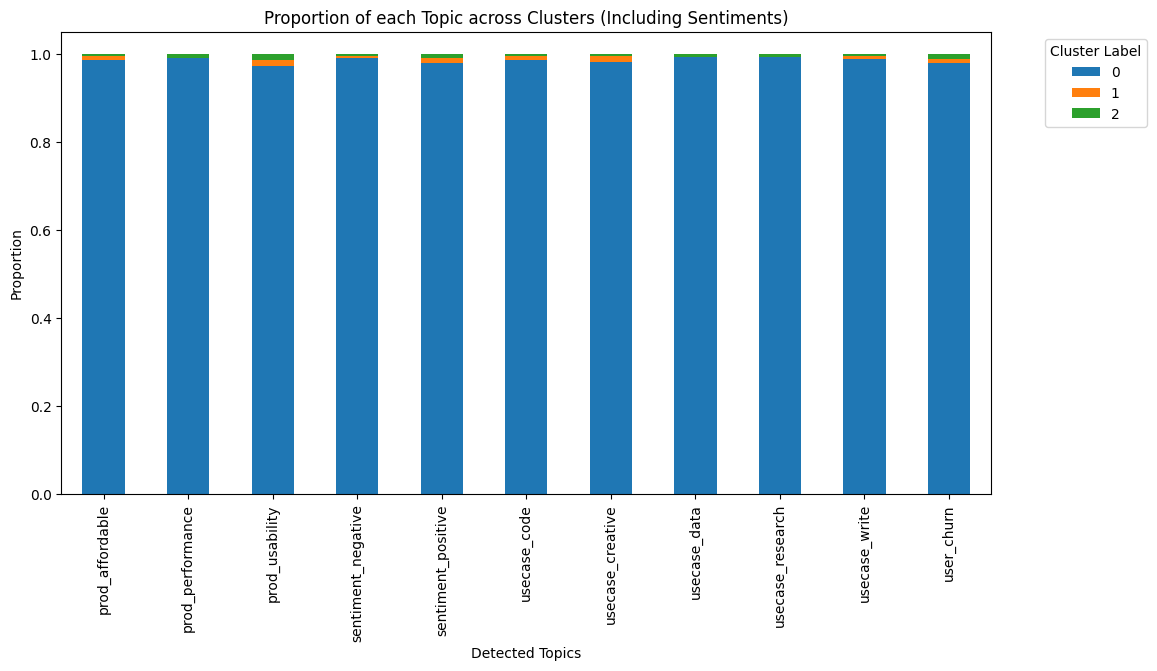

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import functions as F

# Convert relevant columns from PySpark DataFrame to Pandas DataFrame for analysis and plotting
df_posts = df_clustered_spark.select('detected_topics', 'cluster_label', 'prediction', 'AI_Name').toPandas()

# สัดส่วนของ Topic ในแต่ละ Cluster
df_exploded = df_posts.explode('detected_topics')

topic_proportion_with_sentiments = pd.crosstab(df_exploded['cluster_label'], df_exploded['detected_topics'], normalize='index')
print("Proportion of Topics by Cluster:")
print(topic_proportion_with_sentiments)

topic_proportion_with_sentiments.plot(kind='bar', stacked=True, figsize=(12, 6), cmap='Set3')
plt.title('Proportion of Topics by Cluster')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# สัดส่วนของแต่ละ Topic กระจายในแต่ละ Cluster
topic_proportion_swapped_with_sentiments = pd.crosstab(df_exploded['detected_topics'], df_exploded['cluster_label'], normalize='index')
print("Proportion of each Topic across Clusters:")
print(topic_proportion_swapped_with_sentiments)

topic_proportion_swapped_with_sentiments.plot(kind='bar', stacked=True, figsize=(12, 6), cmap='Set3')
plt.title('Proportion of each Topic across Clusters')
plt.xlabel('Detected Topics')
plt.ylabel('Proportion')
plt.legend(title='Cluster Label', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

Proportion of Topics by Cluster:
detected_topics  prod_affordable  prod_performance  prod_usability  \
cluster_label                                                        
0                       0.127542          0.065150        0.074802   
1                       0.136364          0.000000        0.136364   
2                       0.105263          0.105263        0.157895   

detected_topics  usecase_code  usecase_creative  usecase_data  \
cluster_label                                                   
0                    0.208549          0.134092      0.052051   
1                    0.272727          0.227273      0.000000   
2                    0.157895          0.105263      0.052632   

detected_topics  usecase_research  usecase_write  user_churn  
cluster_label                                                 
0                        0.166150       0.140641    0.031024  
1                        0.045455       0.136364    0.045455  
2                        0.157895     

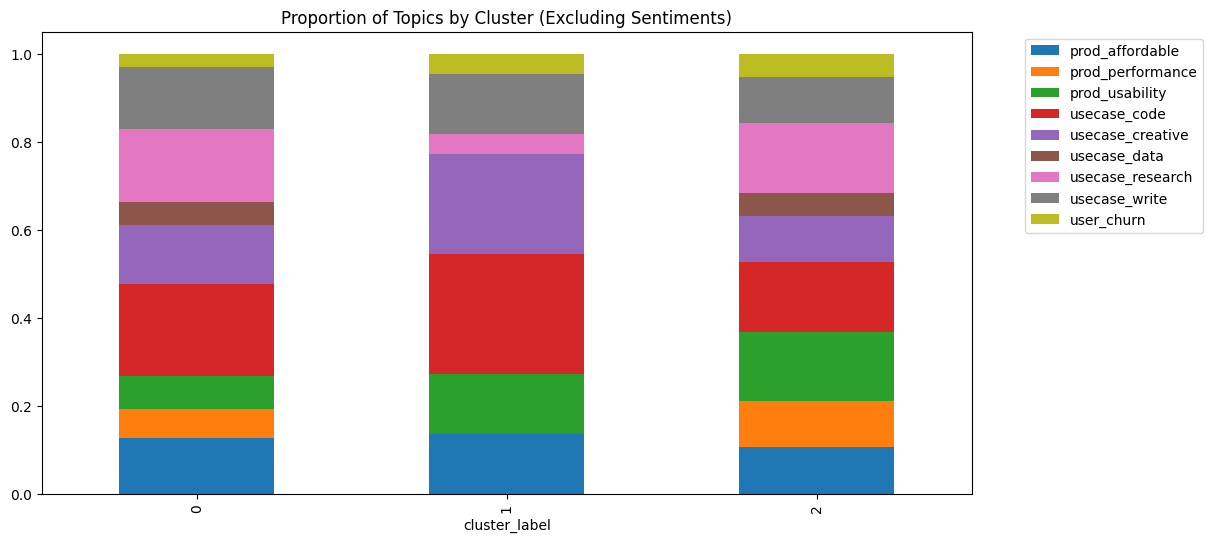

Proportion of each Topic across Clusters (Excluding Sentiments):
cluster_label            0         1         2
detected_topics                               
prod_affordable   0.986667  0.008000  0.005333
prod_performance  0.989529  0.000000  0.010471
prod_usability    0.973094  0.013453  0.013453
usecase_code      0.985342  0.009772  0.004886
usecase_creative  0.982323  0.012626  0.005051
usecase_data      0.993421  0.000000  0.006579
usecase_research  0.991770  0.002058  0.006173
usecase_write     0.987893  0.007264  0.004843
user_churn        0.978261  0.010870  0.010870


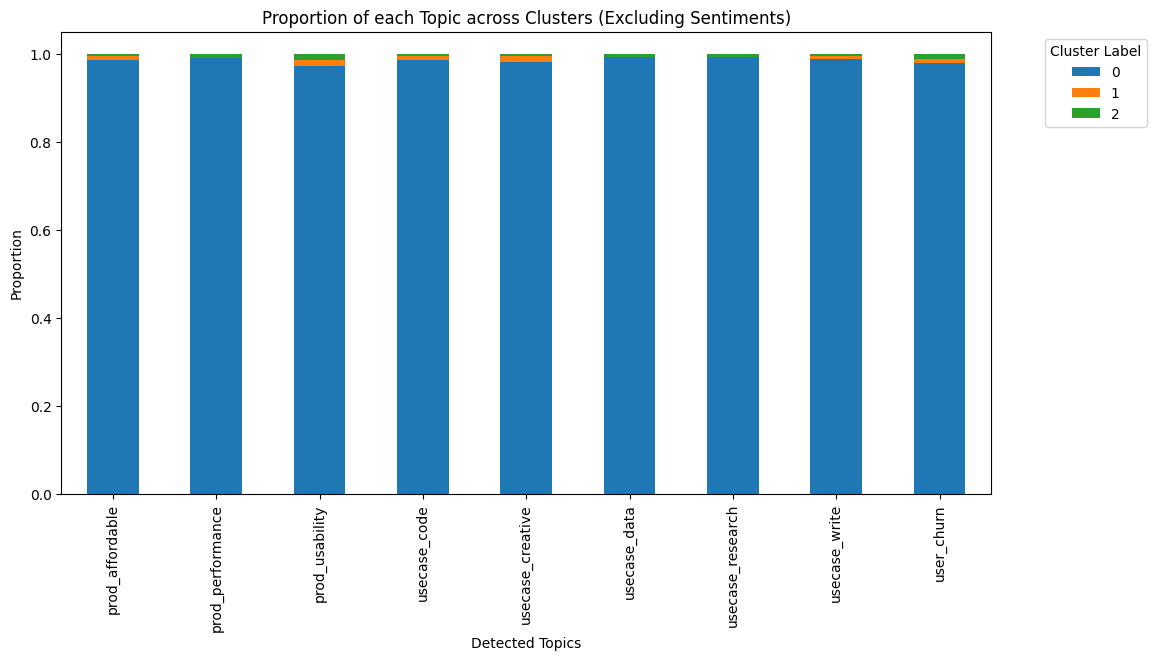

In [35]:
# Filter out 'sentiment_negative' and 'sentiment_positive'
df_exploded_filtered = df_exploded[~df_exploded['detected_topics'].isin(['sentiment_negative', 'sentiment_positive'])]

topic_proportion = pd.crosstab(df_exploded_filtered['cluster_label'], df_exploded_filtered['detected_topics'], normalize='index')
print("Proportion of Topics by Cluster:")
print(topic_proportion)

topic_proportion.plot(kind='bar', stacked=True, figsize=(12, 6), cmap='Set3')
plt.title('Proportion of Topics by Cluster')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# สัดส่วนของแต่ละ Topic กระจายในแต่ละ Cluster
topic_proportion_swapped = pd.crosstab(df_exploded_filtered['detected_topics'], df_exploded_filtered['cluster_label'], normalize='index')
print("Proportion of each Topic across Clusters:")
print(topic_proportion_swapped)

topic_proportion_swapped.plot(kind='bar', stacked=True, figsize=(12, 6), cmap='Set3')
plt.title('Proportion of each Topic across Clusters')
plt.xlabel('Detected Topics')
plt.ylabel('Proportion')
plt.legend(title='Cluster Label', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

Proportion of Sentiment by Cluster:
prediction          0.0       1.0       2.0
cluster_label                              
0              0.694883  0.229319  0.075798
1              0.777778  0.222222  0.000000
2              0.800000  0.200000  0.000000


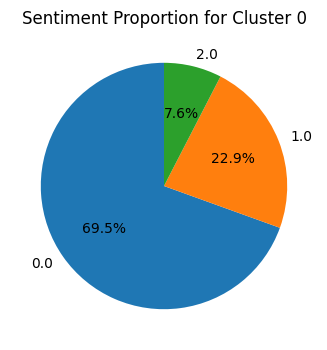

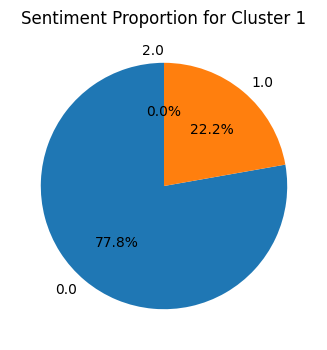

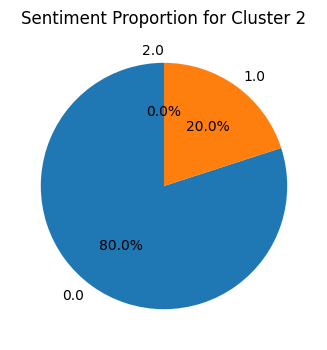

Proportion of each Sentiment across Clusters:
cluster_label         0         1         2
prediction                                 
0.0            0.987965  0.007659  0.004376
1.0            0.990033  0.006645  0.003322
2.0            1.000000  0.000000  0.000000


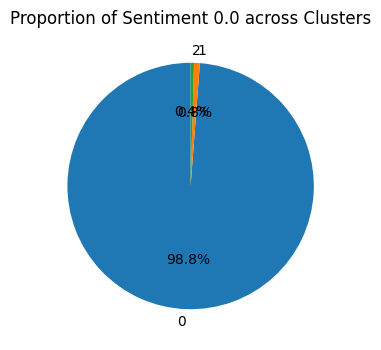

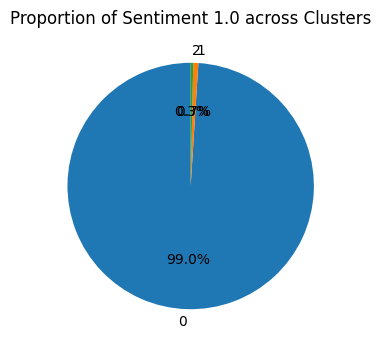

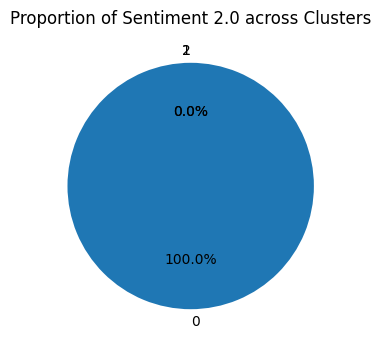

In [32]:
# สัดส่วนของ Sentiment ในแต่ละ Cluster
sentiment_proportion = pd.crosstab(df_posts['cluster_label'], df_posts['prediction'], normalize='index')
print("Proportion of Sentiment by Cluster:")
print(sentiment_proportion)

# Define a colormap for the pie charts
colors = plt.cm.Set3.colors

for cluster_label in sentiment_proportion.index:
    plt.figure(figsize=(8, 4))
    plt.pie(sentiment_proportion.loc[cluster_label], labels=sentiment_proportion.columns, autopct='%1.1f%%', startangle=90, colors=colors)
    plt.title(f'Sentiment Proportion for Cluster {int(cluster_label)}')
    plt.show()

# สัดส่วนของแต่ละ Sentiment กระจายในแต่ละ Cluster
sentiment_proportion_swapped = pd.crosstab(df_posts['prediction'], df_posts['cluster_label'], normalize='index')
print("Proportion of each Sentiment across Clusters:")
print(sentiment_proportion_swapped)

for sentiment_pred in sentiment_proportion_swapped.index:
    plt.figure(figsize=(8, 4))
    plt.pie(sentiment_proportion_swapped.loc[sentiment_pred], labels=sentiment_proportion_swapped.columns, autopct='%1.1f%%', startangle=90, colors=colors)
    plt.title(f'Proportion of Sentiment {sentiment_pred} across Clusters')
    plt.show()

Proportion of Product by Cluster:
AI_Name         ChatGPT    Claude  DeepSeek    Gemini      Grok
cluster_label                                                  
0              0.615621  0.134667  0.031551  0.111966  0.106195
1              0.833333  0.000000  0.000000  0.166667  0.000000
2              0.900000  0.100000  0.000000  0.000000  0.000000


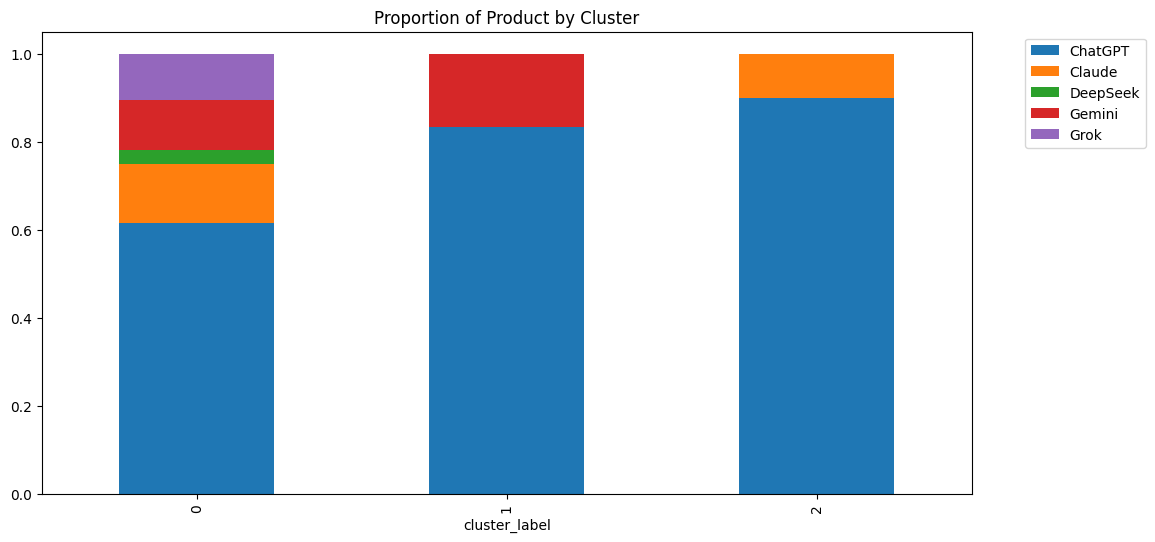

Proportion of each AI Product across Clusters:
cluster_label         0         1         2
AI_Name                                    
ChatGPT        0.985222  0.009236  0.005542
Claude         0.997151  0.000000  0.002849
DeepSeek       1.000000  0.000000  0.000000
Gemini         0.989796  0.010204  0.000000
Grok           1.000000  0.000000  0.000000


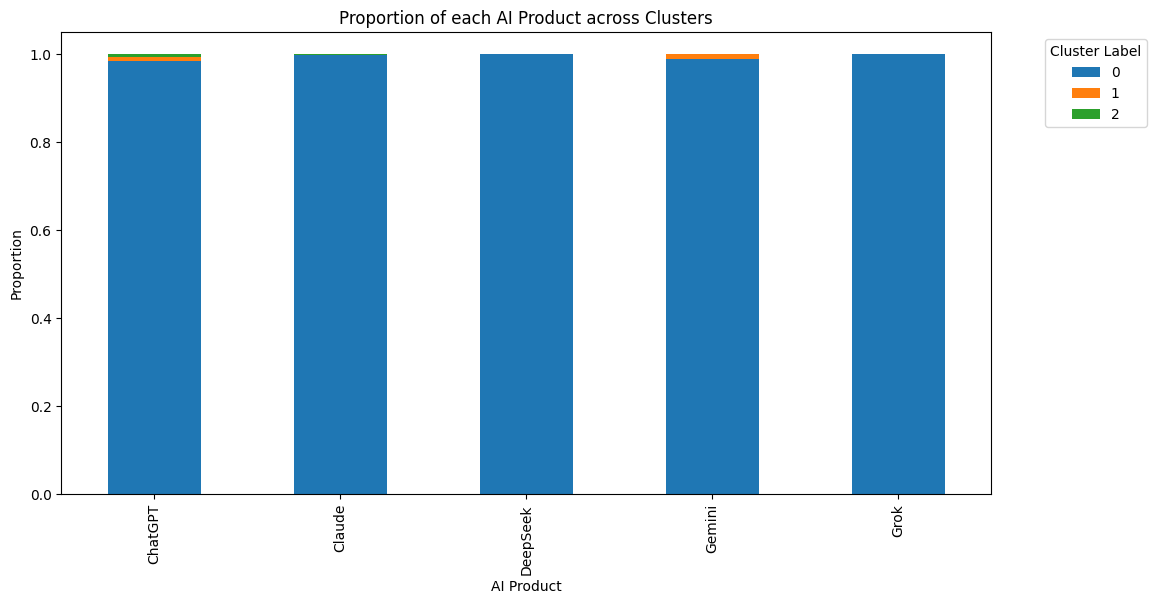

In [29]:
# สัดส่วนของ AI Product ในแต่ละ Cluster
product_proportion = pd.crosstab(df_posts['cluster_label'], df_posts['AI_Name'], normalize='index')
print("Proportion of Product by Cluster:")
print(product_proportion)

product_proportion.plot(kind='bar', stacked=True, figsize=(12, 6), cmap='Set3')
plt.title('Proportion of Product by Cluster')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# สัดส่วนของแต่ละ AI Product กระจายในแต่ละ Cluster
product_proportion_swapped = pd.crosstab(df_posts['AI_Name'], df_posts['cluster_label'], normalize='index')
print("Proportion of each AI Product across Clusters:")
print(product_proportion_swapped)

product_proportion_swapped.plot(kind='bar', stacked=True, figsize=(12, 6), cmap='Set3')
plt.title('Proportion of each AI Product across Clusters')
plt.xlabel('AI Product')
plt.ylabel('Proportion')
plt.legend(title='Cluster Label', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()